## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"
pert_path = project_dir / "2_noise_pert.py"

In [2]:
import calculate_metrics_naive

In [3]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tools.eval_measures import rmse
import andes

andes.config_logger(stream_level=30)

In [4]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")

In [5]:
# TDS Constants
STEP_TIME = 0.01 # 10 ms

In [6]:
ss_true = andes.load(case_path, setup=False)

ss_true.setup()
ss_true.config.warn_abnormal = 0
ss_true.PFlow.run()

ss_true.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
ss_true.TDS.config.fixt = 1 # fixed step size
ss_true.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss_true.TDS.config.no_tqdm = 1
ss_true.TDS.config.criteria = 1
ss_true.TDS.run()

True

## Run TDS & Initial Results

In [7]:
ss = andes.load(case_path, pert=pert_path)
#ss.REGF2.set("Tr",1,0.05)
print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]
pert() applied at grid_t=0.0
Old value: 0.2
Psen_y_noise: 0.1774109422769535
state: {'last_t': None, 'ou_vd': np.float64(0.0007520035539294849), 'ou_vq': np.float64(-0.002566550403257001), 'ou_id': np.float64(0.004630048689360352), 'ou_iq': np.float64(0.005802989530459563), 'last_grid_t': 0.0}
pert() applied at grid_t=0.01
Old value: 0.19999993733848234
Psen_y_noise: 0.17735815304268973
state: {'last_t': None, 'ou_vd': np.float64(-0.0040995823587442375), 'ou_vq': np.float64(-0.005654994046587318), 'ou_id': np.float64(0.005192973772999936), 'ou_iq': np.float64(0.0035688567059990574), 'last_grid_t': 0.01}
pert() applied at grid_t=0.02
Old value: 0.19989874009377395
Psen_y_noise: 0.1820220393418901
state: {'last_t': None, 'ou_vd': np.float64(-0.0039411065183526765), 'ou_vq': np.float64(-0.007484402209355088), 'ou_id': np.float64(0.010365319358209132), 'ou_iq': np.float64(0.008193533994912476), 'last_grid_t': 0.02}
pert() applied at grid_t=0.03
Old value: 0.19967526296559482
Psen_y

System has been setup. Calling setup() twice is not allowed. To add devices, reload the case with setup=False, add devices, then call setup().


pert() applied at grid_t=0.29
Old value: 0.2010970513364149
Psen_y_noise: 0.17939578018312333
state: {'last_t': None, 'ou_vd': np.float64(-0.00915297065620119), 'ou_vq': np.float64(-0.006788906557457365), 'ou_id': np.float64(0.007250204561736542), 'ou_iq': np.float64(-0.008477881189090803), 'last_grid_t': 0.29}
pert() applied at grid_t=0.3
Old value: 0.2021129733968217
Psen_y_noise: 0.18063463873022392
state: {'last_t': None, 'ou_vd': np.float64(-0.011232438517355092), 'ou_vq': np.float64(-0.006015377884308504), 'ou_id': np.float64(0.008253918506691847), 'ou_iq': np.float64(0.00032135133014329215), 'last_grid_t': 0.3}
pert() applied at grid_t=0.31
Old value: 0.20298213382559435
Psen_y_noise: 0.18939029908079133
state: {'last_t': None, 'ou_vd': np.float64(-0.008623676160057138), 'ou_vq': np.float64(-0.004841291405918052), 'ou_id': np.float64(0.016879490395841183), 'ou_iq': np.float64(-0.007028616650176806), 'last_grid_t': 0.31}
pert() applied at grid_t=0.32
Old value: 0.2032954617856642

True

In [8]:
def visualize_cf_noise(noisy, true, var, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_title(f"{var}: Noisy vs. Noiseless Signal Inputs")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"{var} (p.u.)")

    # plot actual
    ax.plot(noisy.index, noisy, "s-", color="tab:orange",
                    markersize=0.5, label="Noisy Inputs", alpha=1)
    ax.plot(true.index, true, "s-", color="tab:blue",
            markersize=0.5, label="Noiseless Inputs", alpha=0.6)
    

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)


    plt.tight_layout()

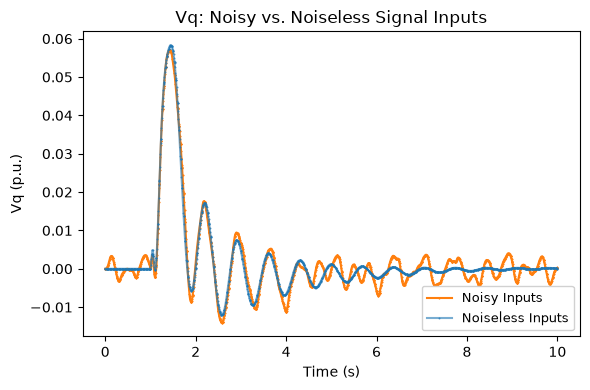

In [9]:
vq = ss.TDS.get_timeseries(ss.REGF2.vq)
vq_t = ss_true.TDS.get_timeseries(ss_true.REGF2.vq)

visualize_cf_noise(vq, vq_t, "Vq")

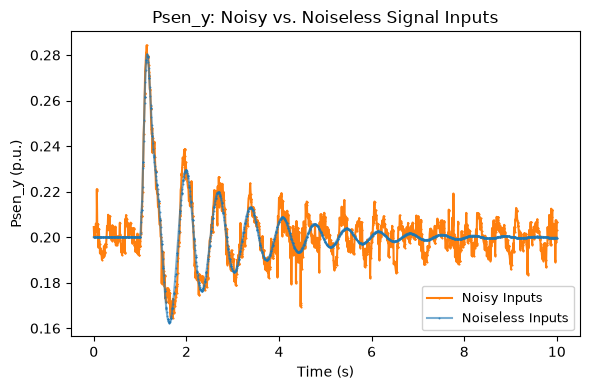

In [10]:
psen = ss.TDS.get_timeseries(ss.REGF2.Psen_y)
psen_t = ss_true.TDS.get_timeseries(ss_true.REGF2.Psen_y)

visualize_cf_noise(psen, psen_t, "Psen_y")

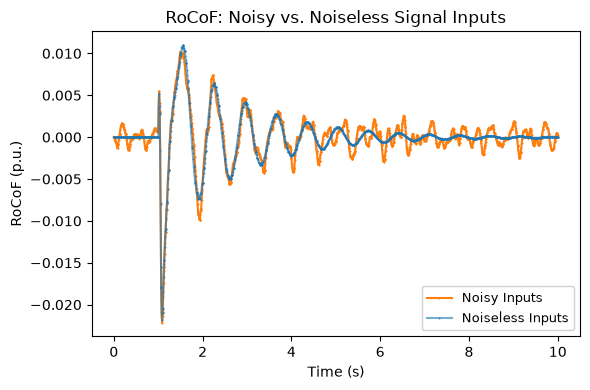

In [13]:
f1 = ss.TDS.get_timeseries(ss.BusFreq.f).loc[:,"BusFreq_1"]
rc1 = calculate_metrics_naive.calculate_rocof(f1)

f2 = ss_true.TDS.get_timeseries(ss_true.BusFreq.f).loc[:,"BusFreq_1"]
rc2 = calculate_metrics_naive.calculate_rocof(f2)

visualize_cf_noise(rc1, rc2, "RoCoF")

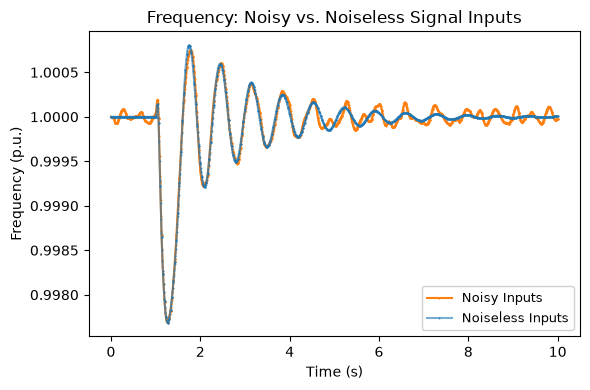

In [14]:
visualize_cf_noise(f1, f2, "Frequency")

## Metrics

In [11]:
metrics_df, h_series = calculate_metrics_naive.calculate_metrics(ss, True)
metrics_df

,Tr (s),Pref,Peak Inertial Power,Power Available,H_RMSE (s),Max RoCoF,Nadir,Settling Time (s)
0,0.005,0.2,0.281145,1.0,4.348151,0.022144,0.99769,10.0


In [15]:
_, h_true = calculate_metrics_naive.calculate_metrics(ss_true, True)

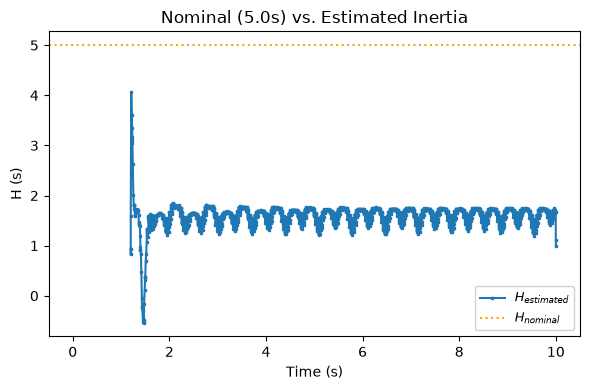

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1)
H_t = h_true

plot_title = f"Nominal ({H_gfm}s) vs. Estimated Inertia"
ax.set_title(plot_title)
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (s)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue", markersize=1.8, label = f"$H_{{estimated}}$")

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label=f"$H_{{nominal}}$")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

#ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
#plt.xlim(0, 6)
#plt.ylim(-1, 50)
plt.tight_layout()

#plt.savefig(f'{out_dir}/1_testbench_figs/{plot_title}.png', dpi=300, bbox_inches='tight')

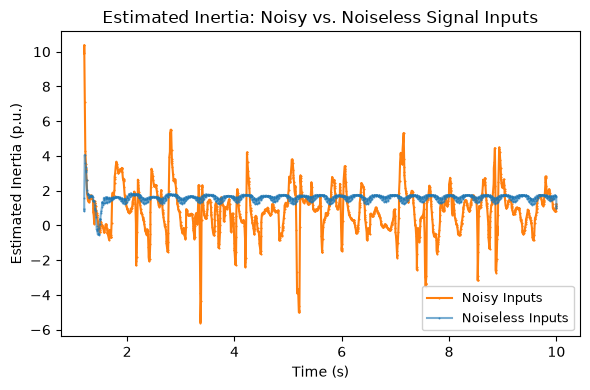

In [16]:
visualize_cf_noise(h_series, h_true, "Estimated Inertia")